In [ ]:
from viz_helpers import *

# Nonlinear moons dataset

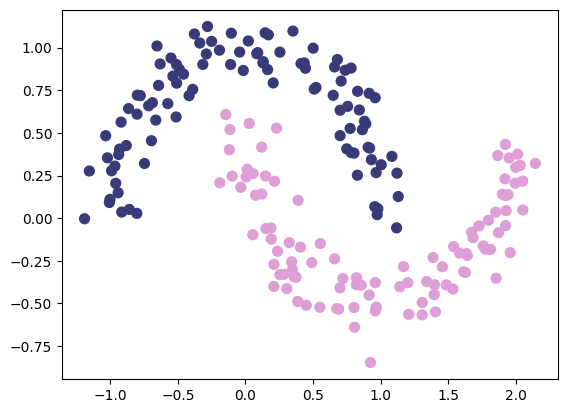

In [ ]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=200, noise=0.1)
plot_2d_clf_problem(X, y)

# Training binary classification model

===== EPOCH : 0 ===== LOSS : 0.70212 =====
===== EPOCH : 500 ===== LOSS : 0.28026 =====
===== EPOCH : 1000 ===== LOSS : 0.02783 =====
Accuracy: 1.0


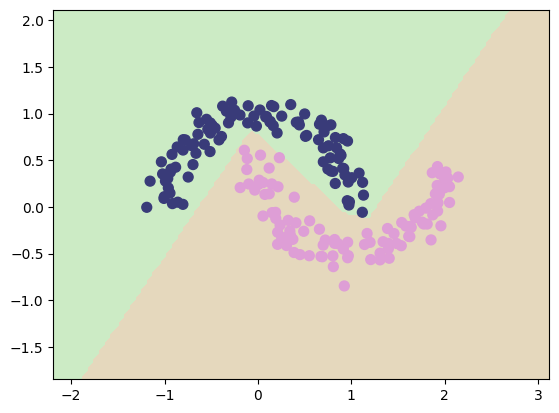

In [ ]:
from dlfs.model import SequentialModel
from dlfs.layers import DenseLayer
from dlfs.activation import ReLU, Sigmoid
from dlfs.loss import BCE_Loss
from dlfs.optimizers import Optimizer_SGD, Optimizer_Adam

layers = [DenseLayer(2, 3), 
          ReLU(),
          DenseLayer(3, 3),
          ReLU(),
          DenseLayer(3, 1),
          Sigmoid()]

model = SequentialModel(layers=layers, loss_function=BCE_Loss(), optimizer=Optimizer_Adam(learning_rate=5e-3))

model.train(X, y.reshape(-1, 1), print_every=500)
print(f'Accuracy: {np.mean(y.reshape(-1, 1) == np.round(model.predict(X)))}')
plot_2d_clf_problem(X, y, lambda x: model.predict(x) > 0.5)

# Extract each layer's output

In [ ]:
model.forward(X)

Z1 = model.wrapper.layers[0].output.copy() # first dense
A1 = model.wrapper.layers[1].output.copy() # first dense + relu
Z2 = model.wrapper.layers[2].output.copy() # second dense
A2 = model.wrapper.layers[3].output.copy() # second dense + relu
Z3 = model.wrapper.layers[4].output.copy() # third dense
A3 = model.wrapper.layers[5].output.copy() # third dense + sigmoid

# Plotting first linear transformation

In [ ]:
plot_3d_output(Z1, y, "2D → 3D using first Dense Layer")

# Plotting first linear transformation and first activation

In [ ]:
plot_3d_output(A1, y, "2D → 3D using first Dense Layer + ReLU")

# Plotting second linear transformation

In [ ]:
plot_3d_output(Z2, y, "3D → 3D using second Dense Layer")

# Plotting second linear transformation and second activation

In [ ]:
plot_3d_output(A2, y, "3D → 3D using second Dense Layer + ReLU")

# Plotting third linear transformation

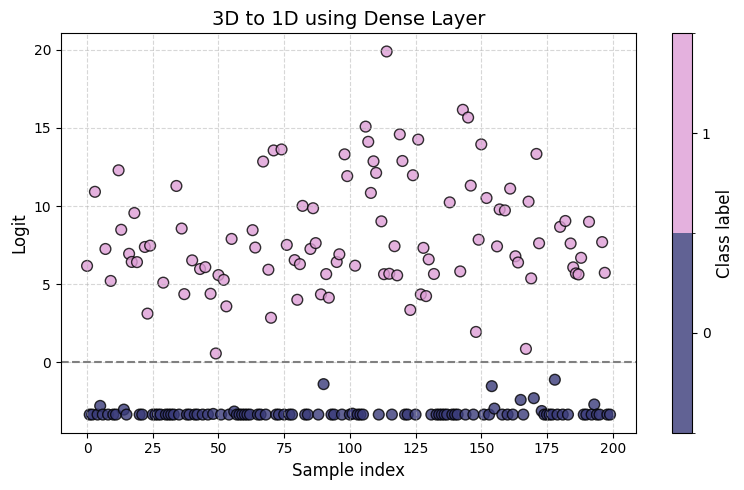

In [ ]:
plot_1d_output(Z3, y, "3D to 1D using Dense Layer", logits=True)

# Plotting third linear transformation and third activation

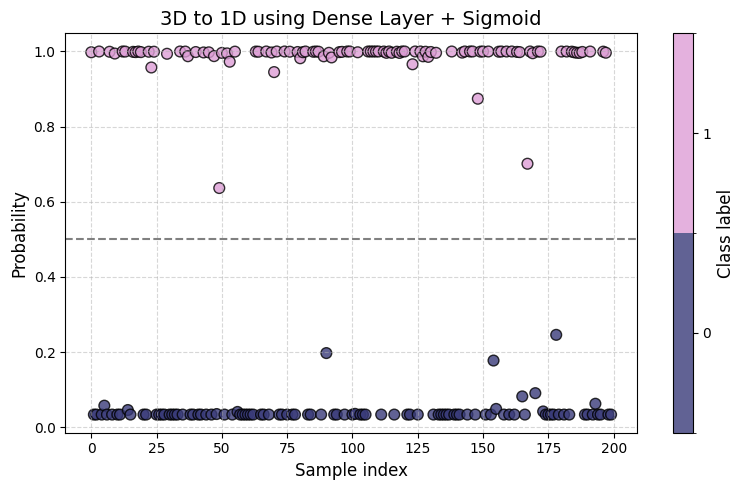

In [ ]:
plot_1d_output(A3, y, "3D to 1D using Dense Layer + Sigmoid", logits=False)